In [2]:
import numpy as np
import json
import random
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

from sklearn.metrics import accuracy_score, confusion_matrix

import matplotlib.pyplot as plt


In [3]:
def calculate_greedy_cost(p_prev, p_curr, p_next, c=0):
    return abs(p_prev - p_curr)
# revise based on previous level

def calculate_planning_cost(p_prev, p_curr, p_next, c=0):

    dist_step_1 = abs(p_prev - p_curr)
    dist_step_2 = abs(p_curr - p_next)
    

    v1 = p_curr - p_prev
    v2 = p_next - p_curr
    
    switch_penalty = c if (v1 * v2 < 0) else 0
    
    return dist_step_1 + dist_step_2 + switch_penalty

In [4]:
def generate_levels(num_levels=50, screen_width=1, 
                    greedy_func=calculate_greedy_cost, 
                    planning_func=calculate_planning_cost, 
                    c=0,
                    degree_of_conflict=1.5):
    
    experiment_configs = []
    
    while len(experiment_configs) < num_levels:
        # --- LEVEL 1 ---
        # Constraint: Between 0.2 and 0.8
        h1_entry = random.uniform(0.2, 0.8)
        
        # --- LEVEL 2 ---
        # Constraint: Must be at least 0.1 away from h1
        # Left side:  0 to (h1 - 0.1)
        # Right side: (h1 + 0.1) to 1
        
        # Safety check: ensure bounds are valid (though 0.2-0.8 range ensures they usually are)
        max_left = h1_entry - 0.15
        min_right = h1_entry + 0.15
        
        # If the gap is too small or out of bounds, restart
        if max_left <= 0 or min_right >= 1: 
            continue

        h2_left_side = random.uniform(0, max_left)
        h2_right_side = random.uniform(min_right, 1)
        

        # --- LEVEL 3 ---
        # Constraint: Must be at least 0.1 away from BOTH h2 holes
        # Since h3 is between the two holes, it must be:
        # Greater than (h2_left + 0.1) AND Less than (h2_right - 0.1)
        
        min_h3 = h2_left_side + 0.1
        max_h3 = h2_right_side - 0.1
        
        # If the gap between level 2 holes is too tight (< 0.2), 
        # we cannot fit a hole in level 3. Restart.
        if min_h3 >= max_h3:
            continue

        h3_goal_x = random.uniform(min_h3, max_h3)
        
        # Final screen width check
        if not (0 < h3_goal_x < screen_width):
            continue

        # --- CALCULATE COSTS ---
        cost_g_left = greedy_func(h1_entry, h2_left_side, h3_goal_x, c)
        cost_p_left = planning_func(h1_entry, h2_left_side, h3_goal_x, c)
        
        cost_g_right = greedy_func(h1_entry, h2_right_side, h3_goal_x, c)
        cost_p_right = planning_func(h1_entry, h2_right_side, h3_goal_x, c)

        if True:
            trial = {
                "trial_id": len(experiment_configs) + 1,
                "levels": [
                    {"level": 1, "holes": [h1_entry]},
                    {"level": 2, "holes": [h2_left_side, h2_right_side]},
                    {"level": 3, "holes": [h3_goal_x]}
                ],
                "metadata": {
                    "left_greedy_cost": cost_g_left,
                    "right_greedy_cost": cost_g_right,
                    "left_planning_cost": cost_p_left,
                    "right_planning_cost": cost_p_right,
                }
            }
            experiment_configs.append(trial)
            
    return experiment_configs

In [5]:
trials = generate_levels(num_levels=10000)
print(trials[1])

with open('trials_output.json', 'w') as f:
    json.dump(trials, f, indent=4)


{'trial_id': 2, 'levels': [{'level': 1, 'holes': [0.40034569181663715]}, {'level': 2, 'holes': [0.08921732100561479, 0.9859991476904328]}, {'level': 3, 'holes': [0.3235884691741821]}], 'metadata': {'left_greedy_cost': 0.31112837081102235, 'right_greedy_cost': 0.5856534558737957, 'left_planning_cost': 0.5454995189795897, 'right_planning_cost': 1.2480641343900465}}


In [6]:
def get_trial_features(trials):
    greedy_choice_is_left = []
    matrix_rows = []

    for trial in trials:
        meta = trial['metadata']
        levels = trial['levels']
        
        g_cost_L = meta['left_greedy_cost']
        g_cost_R = meta['right_greedy_cost']
        p_cost_L = meta['left_planning_cost']
        p_cost_R = meta['right_planning_cost']
        
        greedy_choice_is_left.append(1 if g_cost_L < g_cost_R else 0)

        matrix_rows.append([g_cost_L, g_cost_R, p_cost_L, p_cost_R])

    return np.array(greedy_choice_is_left).reshape(-1, 1), np.array(matrix_rows)

In [7]:
data = get_trial_features(trials)
y = pd.DataFrame(data[0])
X = pd.DataFrame(data[1])
feature_names = ['Left Greedy Cost', 'Right Greedy Cost', 'Left Planning Cost', 'Right Planning Cost']

#model = sm.Logit(y, X).fit(disp = 0)
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)
model = LogisticRegression(solver='liblinear', random_state=0)
model.fit(X_train, y_train)

coefficients = pd.Series(model.coef_[0], index=feature_names)
print(coefficients)

Left Greedy Cost      -14.417016
Right Greedy Cost      14.453345
Left Planning Cost     -1.398974
Right Planning Cost     1.471632
dtype: float64


c:\Users\manik\anaconda3\Lib\site-packages\sklearn\utils\validation.py:1184: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [8]:
y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy Score: {accuracy:.2f}")

cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)

Accuracy Score: 0.98
Confusion Matrix:
[[598  16]
 [ 13 623]]


In [17]:
def calculate_agreement(experiment_configs):
    agreements = 0
    total_trials = len(experiment_configs)

    for trial in experiment_configs:
        meta = trial['metadata']
        

        if meta['left_greedy_cost'] < meta['right_greedy_cost']:
            greedy_choice = 'Left'
        else:
            greedy_choice = 'Right'
            
        if meta['left_planning_cost'] < meta['right_planning_cost']:
            planning_choice = 'Left'
        else:
            planning_choice = 'Right'
            
        if greedy_choice == planning_choice:
            agreements += 1

    agreement_rate = agreements / total_trials
    print(f"Total Trials:    {total_trials}")
    print(f"Agreed Trials:   {agreements}")
    print(f"Agreement Rate:  {agreement_rate:.2%}")
    

my_levels = generate_levels(num_levels=10000)

agreement_pct = calculate_agreement(my_levels)

Total Trials:    10000
Agreed Trials:   7577
Agreement Rate:  75.77%


Total Training Pool: 4000 trials
Fixed Test Set: 1000 trials


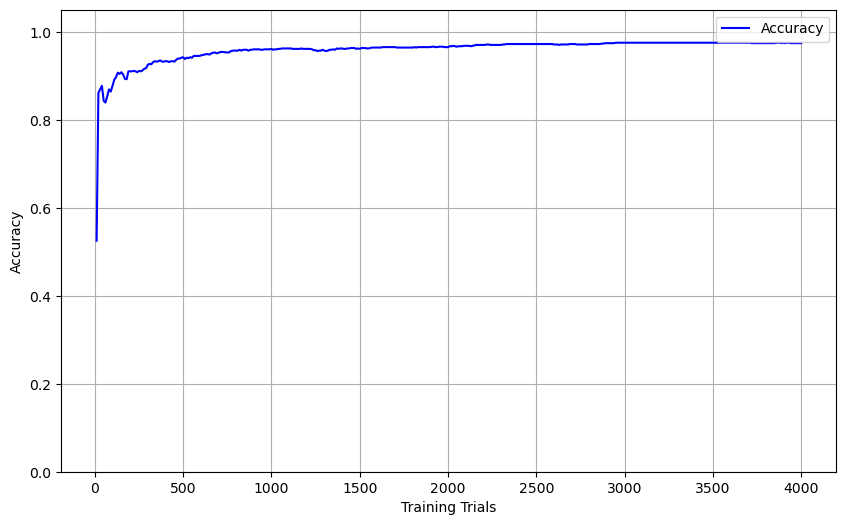

In [16]:
data = get_trial_features(trials)
y = pd.DataFrame(data[0])
X = pd.DataFrame(data[1])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

train_sizes = []
accuracies = []

chunk_size = 10
max_train_size = len(X_train)

print(f"Total Training Pool: {max_train_size} trials")
print(f"Fixed Test Set: {len(X_test)} trials")

model = LogisticRegression(solver='liblinear', random_state=0)

for n in range(chunk_size, max_train_size + 1, chunk_size):
    X_subset = X_train.iloc[:n]
    y_subset = y_train.iloc[:n]
    
    model.fit(X_subset, y_subset.values.ravel())
    
    y_pred = model.predict(X_test)
    
    acc = accuracy_score(y_test, y_pred)
    
    train_sizes.append(n)
    accuracies.append(acc)

plt.figure(figsize=(10, 6))
plt.plot(train_sizes, accuracies, linestyle='-', color='b', label='Accuracy')
plt.xlabel('Training Trials')
plt.ylabel('Accuracy')
plt.grid(True)
plt.ylim(0, 1.05)
plt.legend()
plt.show()